# Aplicacion modelos

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import time 
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [2]:
covertype = fetch_ucirepo(id=31)

In [3]:
X = covertype.data.features
y = covertype.data.targets

In [4]:
X.drop(["Hillshade_9am"], axis=1, inplace=True)

d:\Miniconda\envs\ml_venv\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
loaded_SMOTE = pd.read_csv('datos_smote.csv')
X_train_SM = loaded_SMOTE.drop('Cover_Type', axis=1)
y_train_SM = loaded_SMOTE['Cover_Type']

In [8]:
loaded_ADA = pd.read_csv('datos_ada.csv')
X_train_ADA = loaded_SMOTE.drop('Cover_Type', axis=1)
y_train_ADA = loaded_SMOTE['Cover_Type']

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_sc = scaler.fit_transform(X_test)

In [23]:
def metricas(model, scaled = False):
    if not scaled:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_sc)

    # Precisión del modelo
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Precisión: {accuracy * 100:.2f}%")

    # Matriz de confusión
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    # Reporte de clasificación
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))

In [ ]:
def AUC_curvas(model, scaled = False, draw = True):
    if not scaled:  
        y_pred_prob = model.predict_proba(X_test)
    else:
        y_pred_prob = model.predict_proba(X_test_sc)
    if draw:
        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # Calcular FPR, TPR y AUC para cada clase
        for i in range(7):
            fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Graficar las curvas ROC para cada clase
        plt.figure(figsize=(8, 6))
        colors = ['blue', 'red', 'green', 'yellow', 'orange', 'purple', 'black']
        for i, color in zip(range(7), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2)
        plt.xlabel('Tasa de falsos positivos (FPR)')
        plt.ylabel('Tasa de verdaderos positivos (TPR)')
        plt.title('Curva ROC multiclase (One-vs-Rest)')
        plt.legend(loc='lower right')
        plt.show()

    # Calcular el AUC promedio (macro-average)
    auc_avg = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')
    print(f'AUC promedio (macro): {auc_avg:.2f}')

In [ ]:
from sklearn.model_selection import cross_val_score


## K Nearest Neighbors

El algoritmo K-Nearest Neighbors (KNN) funciona según el principio de similitud, es decir, predice la etiqueta o el valor de un nuevo punto de datos teniendo en cuenta las etiquetas o los valores de sus K vecinos más cercanos en el conjunto de datos de entrenamiento. Para realizar esta tarea se usan diversas metricas que nos ayudan a calcular la distancia entre dos puntos dados
1. Distancia euclídeana

La distancia euclídeana se define como la distancia en línea recta entre dos puntos de un plano o espacio. Puedes pensar en ella como el camino más corto que recorrerías si fueras directamente de un punto a otro.

$d(x,X_i) = \sum_{j=1}^d(x_j-X_{i_j})^2$

2. Distancia Manhattan

Es la distancia total que recorrerías si sólo pudieras moverte a lo largo de líneas horizontales y verticales (como una cuadrícula o las calles de una ciudad). También se denomina «distancia del taxi» porque un taxi sólo puede circular por las calles cuadriculadas de una ciudad.

$d(x,y) = \sum_{i=1}^n ∣x_i - y_i∣$

3. Distancia de Minkowski

La distancia de Minkowski es como una familia de distancias, que incluye como casos especiales las distancias euclídeana y de Manhattan.

$d(x,y) = (\sum_{i=1}^n(x_i-y_i)^p)^{\frac{1}{p}}$

De la fórmula anterior podemos decir que cuando p = 2 entonces es igual que la fórmula de la distancia euclídeana y cuando p = 1 entonces obtenemos la fórmula de la distancia Manhattan.

Así pues, podemos pensar en Minkowski como una fórmula de distancia flexible que puede parecerse tanto a la distancia Manhattan como a la distancia euclídeana en función del valor de p

Para la construccion de nuestros modelos usaremos en especifico la metrica Euclídeana

In [14]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib
matplotlib.rc_file_defaults()

In [15]:
neighbors_settings = range(1, 13)

**Dataset desbalanceado**

In [35]:
scores = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree", n_jobs = -1)
    scores.append(np.mean(cross_val_score(clf, X_train, y_train, cv = 5)))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


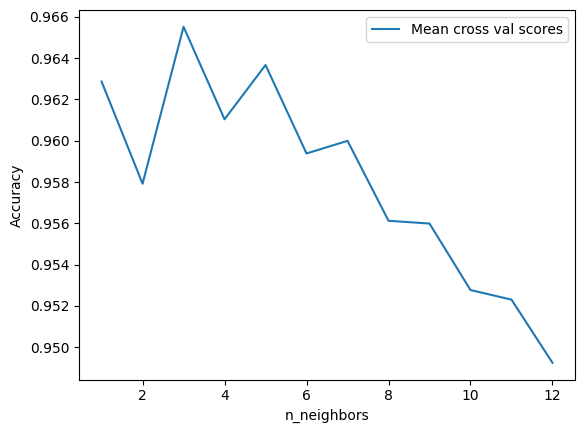

In [41]:
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [42]:
print(f"Mejor modelo = {scores.index(max(scores)) + 1}-NN con media de los cross val {max(scores)}")

Mejor modelo = 3-NN con media de los cross val 0.96552132212801


In [43]:
training_accuracy = []
test_accuracy = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree", n_jobs = -1)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


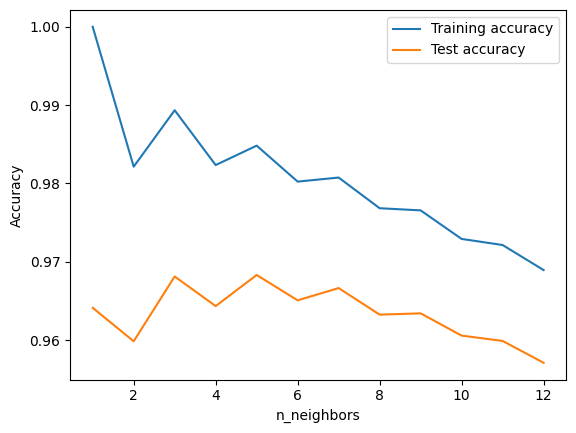

In [44]:
plt.plot(neighbors_settings, training_accuracy, label="Training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="Test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [ ]:
print(f"Mejor modelo = {test_accuracy.index(max(test_accuracy)) + 1}-NN con acurracy de {max(test_accuracy)}")

Mejor modelo = 5-NN con acurracy de 0.968322676695094


**Dataset balanceado con SMOTE**

In [ ]:
scores = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree")
    scores.append(np.mean(cross_val_score(clf, X_train_SM, y_train_SM, cv = 5, n_jobs = -1)))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


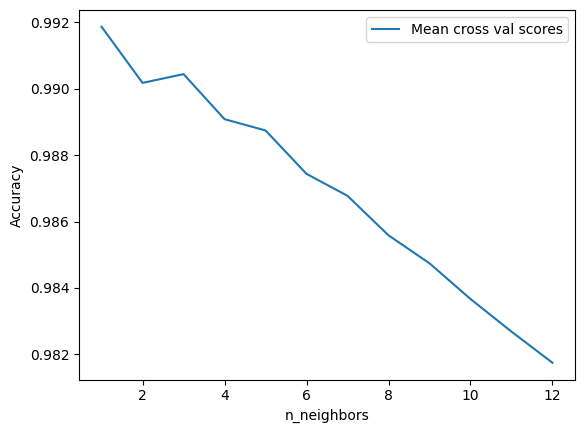

In [17]:
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [18]:
print(f"Mejor modelo = {scores.index(max(scores)) + 1}-NN con media de los cross val {max(scores)}")

Mejor modelo = 1-NN con media de los cross val 0.9918651162607335


In [19]:
training_accuracy = []
test_accuracy = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree", n_jobs = -1)
    clf.fit(X_train_SM, y_train_SM)
    training_accuracy.append(clf.score(X_train_SM, y_train_SM))
    test_accuracy.append(clf.score(X_test, y_test))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


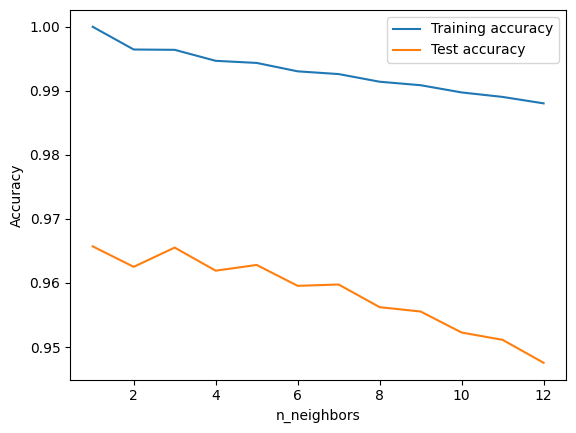

In [20]:
plt.plot(neighbors_settings, training_accuracy, label="Training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="Test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [21]:
print(f"Mejor modelo = {test_accuracy.index(max(test_accuracy)) + 1}-NN con acurracy de {max(test_accuracy)}")

Mejor modelo = 1-NN con acurracy de 0.9657151708647798


**Data balanceado con ADA**

In [16]:
scores = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree")
    scores.append(np.mean(cross_val_score(clf, X_train_ADA, y_train_ADA, cv = 5, n_jobs = -1)))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


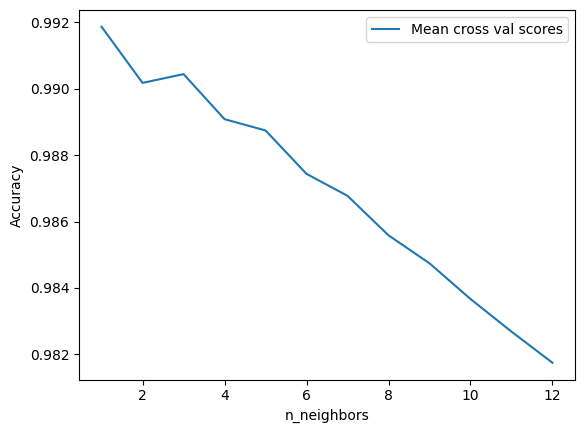

In [17]:
plt.plot(neighbors_settings, scores, label="Mean cross val scores")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [18]:
print(f"Mejor modelo = {scores.index(max(scores)) + 1}-NN con media de los cross val {max(scores)}")

Mejor modelo = 1-NN con media de los cross val 0.9918651162607335


In [19]:
training_accuracy = []
test_accuracy = []

for i in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors = i, algorithm = "kd_tree", n_jobs = -1)
    clf.fit(X_train_ADA, y_train_ADA)
    training_accuracy.append(clf.score(X_train_ADA, y_train_ADA))
    test_accuracy.append(clf.score(X_test, y_test))
    print(f"Modelo {i}-NN hecho")

Modelo 1-NN hecho
Modelo 2-NN hecho
Modelo 3-NN hecho
Modelo 4-NN hecho
Modelo 5-NN hecho
Modelo 6-NN hecho
Modelo 7-NN hecho
Modelo 8-NN hecho
Modelo 9-NN hecho
Modelo 10-NN hecho
Modelo 11-NN hecho
Modelo 12-NN hecho


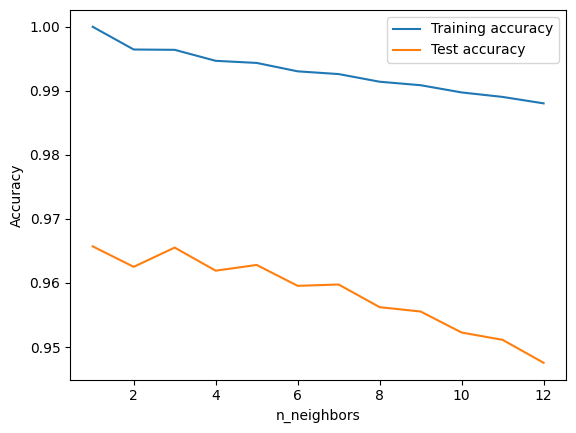

In [20]:
plt.plot(neighbors_settings, training_accuracy, label="Training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="Test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [21]:
print(f"Mejor modelo = {test_accuracy.index(max(test_accuracy)) + 1}-NN con acurracy de {max(test_accuracy)}")

Mejor modelo = 1-NN con acurracy de 0.9657151708647798


Precisión: 96.57%
Matriz de confusión:
[[41039  1304     2     0    44     5   163]
 [ 1430 54605   101     0   252    90    22]
 [    2    50  6906    46    15   102     0]
 [    0     1    32   467     0    26     0]
 [    9    61     8     0  1908     8     1]
 [    0    33    73    24     7  3352     0]
 [   64     9     0     0     0     0  3942]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     42557
           2       0.97      0.97      0.97     56500
           3       0.97      0.97      0.97      7121
           4       0.87      0.89      0.88       526
           5       0.86      0.96      0.90      1995
           6       0.94      0.96      0.95      3489
           7       0.95      0.98      0.97      4015

    accuracy                           0.97    116203
   macro avg       0.93      0.96      0.94    116203
weighted avg       0.97      0.97      0.97    116203



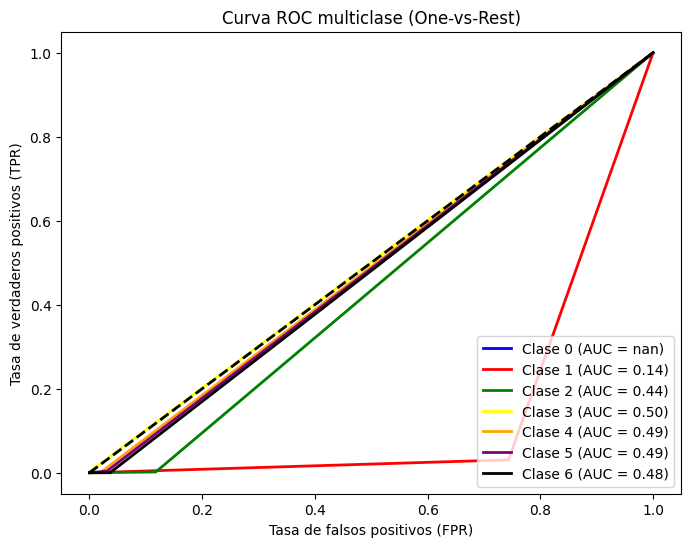

AUC promedio (macro): 0.97
CPU Time: 42.109375 segundos


In [22]:
knn = KNeighborsClassifier(n_neighbors = 1, algorithm = "kd_tree", n_jobs = 1)
start = time.process_time()  # Inicia el contador de CPU time
knn.fit(X_train_SM, y_train_SM)
metricas(knn)
AUC_curvas(knn)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

### Metodos para optimizar el k-nn y CPU-time
Por defecto los k vecinos mas cercanos se encuentran calculando la distancia del punto nuevo a predecir contra todos los puntos cargados como parte del conjunto de entrenamiento. Este proceso puede ser muy computacionalmente costoso con una alto numero de puntos de entrenamiento, por lo cual tenemos un par de algoritmos alternos para poder calcular estos k vecinos mas cercanos en menos tiempo


#### k-d Tree
Un árbol KD (árbol K-Dimensional) es una estructura de datos de partición del espacio que subdivide recursivamente un espacio multidimensional en regiones asociadas a puntos de datos específicos. El objetivo principal de un árbol KD es facilitar las operaciones de búsqueda multidimensional, en particular la búsqueda del vecino más próximo. El algoritmo construye un árbol binario en el que cada nodo representa una región del espacio multidimensional, y el hiperplano asociado está alineado con uno de los ejes de coordenadas. En cada nivel del árbol, el algoritmo selecciona una dimensión para dividir los datos, creando dos nodos hijos. Este proceso continúa recursivamente hasta que se cumple una condición de terminación, como una profundidad predefinida o un número umbral de puntos por nodo. Los árboles KD se utilizan ampliamente en aplicaciones como la búsqueda del vecino más próximo, las consultas de rango y la indexación espacial, y proporcionan una complejidad temporal logarítmica para diversas operaciones de búsqueda en casos medios.

¿Cómo funciona el algoritmo de árbol KD?

Se genera un árbol binario dividiendo recursivamente los datos a lo largo de ejes. El método divide los datos en dos subconjuntos en cada nivel en función del valor medio a lo largo de una dimensión seleccionada. Como resultado de este proceso continuo, se forma un árbol en el que cada nodo representa una región del espacio multidimensional. Los árboles KD reducen el espacio de búsqueda mediante divisiones seleccionadas alineadas con los ejes, lo que permite realizar búsquedas rápidas de vecinos más próximos y consultas espaciales que posibilitan la recuperación eficaz de puntos en campos de alta dimensión.



#### Ball tree
El algoritmo del árbol de bolas es un método de indexación espacial diseñado para organizar y consultar eficazmente datos multidimensionales en geometría computacional y aprendizaje automático. Formalmente, un árbol de bolas divide recursivamente el conjunto de datos encerrando subconjuntos de puntos dentro de hiperesferas. La estructura se construye como un árbol binario, en el que cada nodo que no es hoja representa una hiperesfera que contiene un subconjunto de los datos, y cada nodo hoja corresponde a un pequeño subconjunto de puntos. El proceso de partición consiste en elegir un punto «central» dentro del subconjunto y construir una hiperesfera centrada en ese punto para encerrar los datos. Esta disposición jerárquica facilita la búsqueda rápida del vecino más próximo, ya que permite eliminar rápidamente subárboles enteros durante el proceso de búsqueda. Los árboles de bolas son especialmente útiles en escenarios con datos de gran dimensión, ya que ofrecen una mayor eficiencia que los métodos de búsqueda exhaustiva en aplicaciones como la agrupación, la clasificación y las consultas al vecino más próximo.

¿Cómo funciona el algoritmo del árbol de bolas?

Específicamente concebida para la búsqueda del vecino más próximo, la técnica del árbol de Ball proporciona una estructura de datos para operaciones eficaces de búsqueda multidimensional. Utilizando un árbol binario, crea un subconjunto de puntos de datos rodeados por una hiperesfera en cada nodo. Estas hiperesferas se caracterizan por un radio y un centroide. El método divide los datos en dos subconjuntos y elige una dimensión recursivamente para crear un árbol binario entre ellos. La estructura resultante es especialmente útil en espacios de gran dimensión, en los que los cálculos de distancia convencionales pueden resultar muy costosos, ya que permite eliminar rápidamente los puntos distantes durante la búsqueda del vecino más próximo.



## Regresion Logistica

In [34]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train_sc = scaler.fit_transform(X_train, y_train)

In [57]:
# Modelo con regularización L1
model_l1 = LogisticRegression(
    penalty='l1',         # Tipo de regularización (L1)
    C=0.1,                # Fuerza de regularización (inverso: C=0.1 es alta regularización)
    solver='saga',        # Algoritmo compatible con L1 (otros: 'liblinear')
    max_iter=1000,        # Aumentar si no converge
    random_state=42,
    verbose=1,             # Ver progreso
    n_jobs = -1,
    multi_class= "ovr"
)
start = time.process_time()
model_l1.fit(X_train_sc, y_train)
end = time.process_time()
print(f"CPU Time: {end - start} segundos")

# Modelo con regularización L2 (configuración por defecto)
model_l2 = LogisticRegression(
    penalty='l2',         # Regularización L2 (configuración por defecto)
    C=1.0,                # Valor por defecto
    solver='lbfgs',       # Algoritmo para L2 ('lbfgs', 'newton-cg', 'sag')
    max_iter=1000,
    n_jobs = -1,
    multi_class="ovr"
)
start = time.process_time()
model_l2.fit(X_train_sc, y_train)
end = time.process_time()
print(f"CPU Time: {end - start} segundos")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


convergence after 379 epochs took 508 seconds
convergence after 960 epochs took 1236 seconds
max_iter reached after 1241 seconds
max_iter reached after 1279 seconds
max_iter reached after 1281 seconds
max_iter reached after 1288 seconds
max_iter reached after 1329 seconds
CPU Time: 6367.296875 segundos


[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed: 22.1min finished


CPU Time: 0.4375 segundos


Precisión: 71.52%
Matriz de confusión:
[[29373 12319    35     0     2     0   828]
 [ 9938 45055  1269     2    62   103    71]
 [    0   742  6177    57     0   145     0]
 [    0     0   382    98     0    46     0]
 [   45  1717   206     0    26     1     0]
 [    0  1254  1982    17     2   234     0]
 [ 1822    31    17     0     0     0  2145]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.71      0.69      0.70     42557
           2       0.74      0.80      0.77     56500
           3       0.61      0.87      0.72      7121
           4       0.56      0.19      0.28       526
           5       0.28      0.01      0.02      1995
           6       0.44      0.07      0.12      3489
           7       0.70      0.53      0.61      4015

    accuracy                           0.72    116203
   macro avg       0.58      0.45      0.46    116203
weighted avg       0.70      0.72      0.70    116203



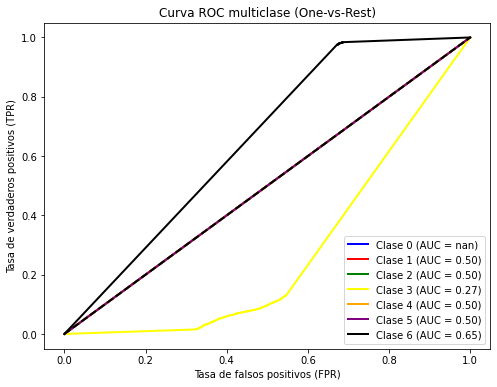

AUC promedio (macro): 0.47


In [58]:
metricas(model_l1, True)
AUC_curvas(model_l1, True)

Precisión: 71.55%
Matriz de confusión:
[[29382 12327    35     0     2     0   811]
 [ 9937 45055  1270     2    62   107    67]
 [    0   740  6146    73     0   162     0]
 [    0     0   330   152     0    44     0]
 [   45  1718   206     0    25     1     0]
 [    0  1252  1964    31     4   238     0]
 [ 1821    31    17     0     0     0  2146]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.71      0.69      0.70     42557
           2       0.74      0.80      0.77     56500
           3       0.62      0.86      0.72      7121
           4       0.59      0.29      0.39       526
           5       0.27      0.01      0.02      1995
           6       0.43      0.07      0.12      3489
           7       0.71      0.53      0.61      4015

    accuracy                           0.72    116203
   macro avg       0.58      0.47      0.48    116203
weighted avg       0.70      0.72      0.70    116203



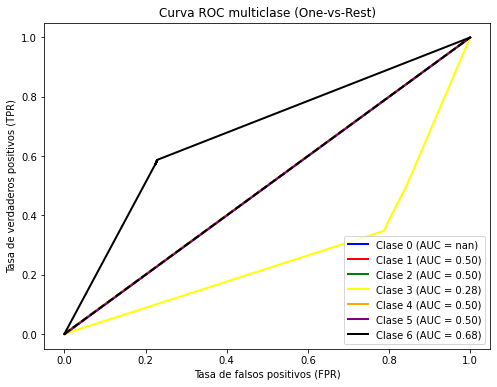

AUC promedio (macro): 0.47


In [59]:
metricas(model_l2, True)
AUC_curvas(model_l2, True)

In [60]:
print("Coeficientes L1:", model_l1.coef_)
print("Coeficientes L2:", model_l2.coef_)

# Contar coeficientes no nulos (L1 tiende a eliminar características)
print("Características no nulas (L1):", np.sum(model_l1.coef_ != 0))
print("Características no nulas (L2):", np.sum(model_l2.coef_ != 0))

Coeficientes L1: [[ 1.96701280e+00 -4.07914441e-02 -1.13931589e-01 -2.98984166e-01
  -9.31559168e-02 -1.48958937e-01 -5.11565740e-01  2.91434613e-01
  -1.27601363e-02  3.34722564e-01  0.00000000e+00 -4.13525245e-01
  -2.75137476e-01 -7.88759246e-02  0.00000000e+00 -1.23808043e-01
  -6.31543326e-02  2.63492003e-03  5.36810259e-02  3.96220935e-02
   3.18117835e-03 -1.33344736e-01 -1.46437781e-02 -4.60995447e-02
   0.00000000e+00  3.50128268e-02  3.05329157e-02 -8.71496838e-03
   5.59115587e-02  1.12488749e-01  1.30363900e-01  2.70391511e-01
   2.50633098e-01  1.15389339e-01 -2.26345386e-02 -6.41514896e-03
   3.97429342e-02 -1.87691467e-02 -6.17643697e-02 -6.74538516e-02
   1.15054864e-01  2.48709939e-02  1.36214659e-01 -8.13320058e-02
  -9.09263403e-02 -2.99139034e-02 -2.17180650e-01 -1.57957083e-01
  -1.52532094e-01 -1.88770425e-01 -8.10714479e-02  1.83186707e-02
  -7.11673899e-01]
 [-1.54724016e+00 -3.59526531e-02  1.15343013e-01  3.26397032e-01
   2.80059954e-02  1.29458889e-01  4.998

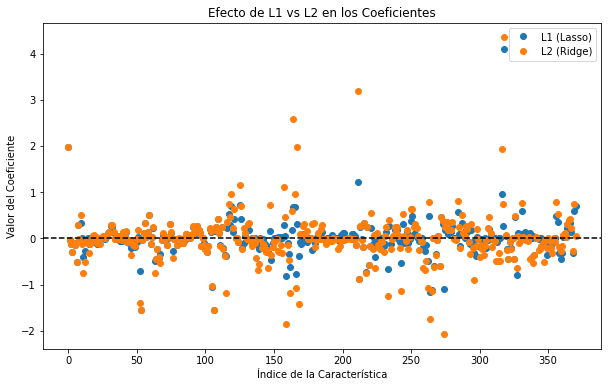

In [61]:
# Coeficientes L1 vs L2
plt.figure(figsize=(10, 6))
plt.plot(model_l1.coef_.flatten(), 'o', label='L1 (Lasso)')
plt.plot(model_l2.coef_.flatten(), 'o', label='L2 (Ridge)')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Índice de la Característica")
plt.ylabel("Valor del Coeficiente")
plt.legend()
plt.title("Efecto de L1 vs L2 en los Coeficientes")
plt.show()

## Bayesiano

In [14]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB

In [16]:
X_train_sc = scaler.fit_transform(X_train, y_train)

CPU Time: 0.640625 segundos
Precisión: 48.62%
Matriz de confusión:
[[    0 42557     0     0     0     0     0]
 [    0 56500     0     0     0     0     0]
 [    0  7121     0     0     0     0     0]
 [    0   526     0     0     0     0     0]
 [    0  1995     0     0     0     0     0]
 [    0  3489     0     0     0     0     0]
 [    0  4015     0     0     0     0     0]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00     42557
           2       0.49      1.00      0.65     56500
           3       0.00      0.00      0.00      7121
           4       0.00      0.00      0.00       526
           5       0.00      0.00      0.00      1995
           6       0.00      0.00      0.00      3489
           7       0.00      0.00      0.00      4015

    accuracy                           0.49    116203
   macro avg       0.07      0.14      0.09    116203
weighted avg       0.24      0.49      0.32    11

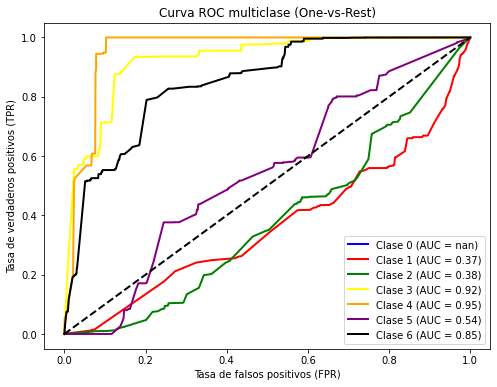

AUC promedio (macro): 0.77


In [19]:
NaiveB = BernoulliNB(alpha = 50000)
start = time.process_time()  # Inicia el contador de CPU time
NaiveB.fit(X_train_sc, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")
metricas(NaiveB)
AUC_curvas(NaiveB)

In [20]:
X_train_SM_sc = scaler.fit_transform(X_train_SM, y_train_SM)

CPU Time: 2.234375 segundos
Precisión: 44.08%
Matriz de confusión:
[[19606  8488    37     0  7478  1016  5932]
 [ 9996 21201  1415   168 16539  5287  1894]
 [    0    10  3165  1559   232  2155     0]
 [    0     0    52   435     0    39     0]
 [    5   184   241     0  1349   216     0]
 [    0    11   655   490   210  2123     0]
 [  370   180    15     0   108     0  3342]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.65      0.46      0.54     42557
           2       0.70      0.38      0.49     56500
           3       0.57      0.44      0.50      7121
           4       0.16      0.83      0.27       526
           5       0.05      0.68      0.10      1995
           6       0.20      0.61      0.30      3489
           7       0.30      0.83      0.44      4015

    accuracy                           0.44    116203
   macro avg       0.38      0.60      0.38    116203
weighted avg       0.63      0.44      0.49    11

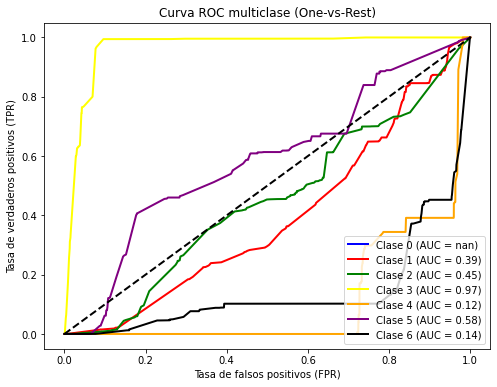

AUC promedio (macro): 0.87


In [ ]:
NaiveB = BernoulliNB()
start = time.process_time()  # Inicia el contador de CPU time
NaiveB.fit(X_train_SM_sc, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print()
print(f"CPU Time: {end - start} segundos")
metricas(NaiveB, True)
AUC_curvas(NaiveB, True)

In [28]:
print("Accuracy on training set: {:.3f}".format(NaiveB.score(X_train, y_train)))

Accuracy on training set: 0.475


In [32]:
X_train_ADA_sc = scaler.fit_transform(X_train_ADA, y_train_ADA)


CPU Time: 2.109375 segundos
Precisión: 44.08%
Matriz de confusión:
[[19606  8488    37     0  7478  1016  5932]
 [ 9996 21201  1415   168 16539  5287  1894]
 [    0    10  3165  1559   232  2155     0]
 [    0     0    52   435     0    39     0]
 [    5   184   241     0  1349   216     0]
 [    0    11   655   490   210  2123     0]
 [  370   180    15     0   108     0  3342]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.65      0.46      0.54     42557
           2       0.70      0.38      0.49     56500
           3       0.57      0.44      0.50      7121
           4       0.16      0.83      0.27       526
           5       0.05      0.68      0.10      1995
           6       0.20      0.61      0.30      3489
           7       0.30      0.83      0.44      4015

    accuracy                           0.44    116203
   macro avg       0.38      0.60      0.38    116203
weighted avg       0.63      0.44      0.49    1

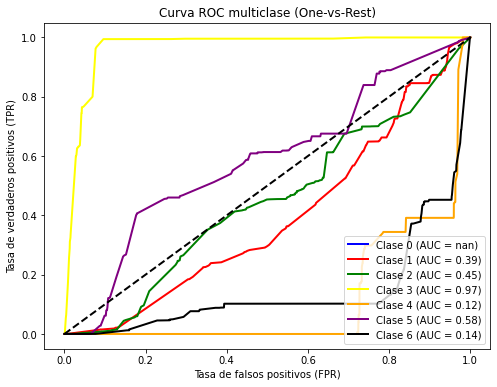

AUC promedio (macro): 0.87


In [33]:
NaiveB = BernoulliNB()
start = time.process_time()  # Inicia el contador de CPU time
NaiveB.fit(X_train_ADA_sc, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print()
print(f"CPU Time: {end - start} segundos")
metricas(NaiveB, True)
AUC_curvas(NaiveB, True)

In [26]:
model = BernoulliNB()
start = time.process_time()  # Inicia el contador de CPU time

# Código a medir
model.fit(X_train, y_train)

end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

CPU Time: 0.6875 segundos


In [45]:
model = GaussianNB()
start = time.process_time()  # Inicia el contador de CPU time

# Código a medir
model.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(model.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(model.score(X_test, y_test)))

end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

Accuracy on training set: 0.457
Accuracy on test set: 0.455
CPU Time: 1.84375 segundos


In [46]:
print(model.score(X_train, y_train))


0.45703288877797116


Precisión: 45.50%
Matriz de confusión:
[[33148  1719   225     0  2309    50  5106]
 [31505  8936  4106    32 11094   164   663]
 [   19     9  5656  1296    91    50     0]
 [    0     0   113   413     0     0     0]
 [  406    33   320     0  1221    15     0]
 [   96     3  2554   348   255   233     0]
 [  675    25    17     0    31     0  3267]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.50      0.78      0.61     42557
           2       0.83      0.16      0.27     56500
           3       0.44      0.79      0.56      7121
           4       0.20      0.79      0.32       526
           5       0.08      0.61      0.14      1995
           6       0.46      0.07      0.12      3489
           7       0.36      0.81      0.50      4015

    accuracy                           0.46    116203
   macro avg       0.41      0.57      0.36    116203
weighted avg       0.64      0.46      0.41    116203



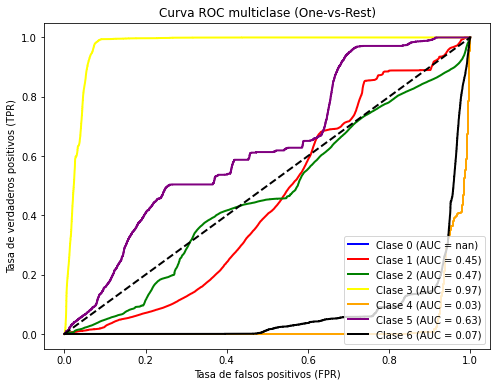

AUC promedio (macro): 0.88


In [47]:
metricas(model)
AUC_curvas(model)

In [ ]:
decision_scores = model.decision_function(X_test)

# Calcular FPR, TPR y AUC para cada clase
n_classes = len(model.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, decision_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f'AUC para la clase {i}: {roc_auc[i]:.2f}')

# Graficar las curvas ROC
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC multiclase (One-vs-Rest) usando decision_function')
plt.legend(loc='lower right')
plt.show()

## Arbol de decision

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


In [33]:
tree = DecisionTreeClassifier(random_state = 42, criterion="entropy")

start = time.process_time()  # Inicia el contador de CPU time
tree.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print("Accuracy on training set: {:.3f}".format(tree.score(X_train_ADA, y_train_ADA)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

print(f"CPU Time: {end - start} segundos")

Accuracy on training set: 1.000
Accuracy on test set: 0.946
CPU Time: 20.5625 segundos


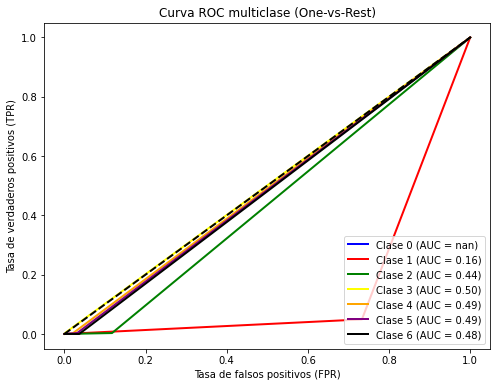

AUC promedio (macro): 0.96


In [ ]:
metricas(tree)
AUC_curvas(tree)

In [ ]:
tree = DecisionTreeClassifier(random_state = 42)
param_grid = {
    "max_depth": [10, 20, 30, None],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", None],
}

In [40]:
tree = DecisionTreeClassifier(random_state = 42, criterion = "entropy")
param_grid = {
    "max_depth": [25, 30, 32, 35, 36, 37, 38, None],
}

CPU Time: 9.234375 segundos
Mejores hiperparámetros: {'max_depth': 36}
Precisión: 94.32%
Matriz de confusión:
[[40088  2256     1     0    36     6   170]
 [ 2287 53730   119     0   236    91    37]
 [    1   121  6698    43    21   237     0]
 [    0     0    58   444     0    24     0]
 [   37   260    14     0  1674     9     1]
 [    7    94   232    24     7  3125     0]
 [  156    14     0     0     0     0  3845]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.95      0.95     56500
           3       0.94      0.94      0.94      7121
           4       0.87      0.84      0.86       526
           5       0.85      0.84      0.84      1995
           6       0.89      0.90      0.90      3489
           7       0.95      0.96      0.95      4015

    accuracy                           0.94    116203
   macro avg       0.91      0.91      0.91    116203
weight

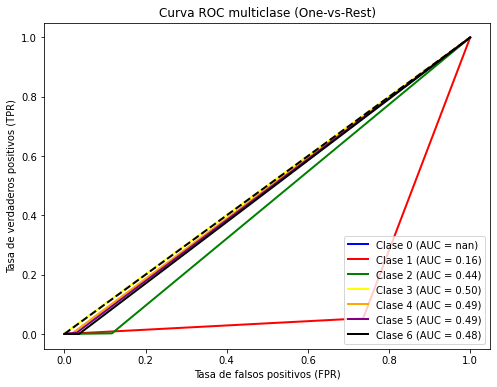

AUC promedio (macro): 0.95


In [42]:
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
AUC_curvas(best_model)

In [41]:
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión: {accuracy * 100:.2f}%")

# Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

CPU Time: 5.859375 segundos
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'max_features': None}
Precisión: 94.39%
Matriz de confusión:
[[40135  2203     1     0    33     7   178]
 [ 2255 53760   122     0   237    92    34]
 [    1   120  6699    43    20   238     0]
 [    0     0    58   444     0    24     0]
 [   33   249    16     0  1687     9     1]
 [    7    96   232    24     6  3124     0]
 [  165    12     0     0     0     0  3838]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.95      0.95     56500
           3       0.94      0.94      0.94      7121
           4       0.87      0.84      0.86       526
           5       0.85      0.85      0.85      1995
           6       0.89      0.90      0.89      3489
           7       0.95      0.96      0.95      4015

    accuracy                           0.94    116203
   macro avg

CPU Time: 8.78125 segundos
Mejores hiperparámetros: {'max_depth': 25}
Precisión: 93.93%
Matriz de confusión:
[[39934  2417     1     0    31     5   169]
 [ 2592 53439   115     0   221    99    34]
 [    1   118  6706    43    18   235     0]
 [    0     0    59   444     0    23     0]
 [   31   272    17     0  1665     9     1]
 [    5    91   232    23     5  3133     0]
 [  166    22     0     0     0     0  3827]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.93      0.94      0.94     42557
           2       0.95      0.95      0.95     56500
           3       0.94      0.94      0.94      7121
           4       0.87      0.84      0.86       526
           5       0.86      0.83      0.85      1995
           6       0.89      0.90      0.90      3489
           7       0.95      0.95      0.95      4015

    accuracy                           0.94    116203
   macro avg       0.91      0.91      0.91    116203
weighte

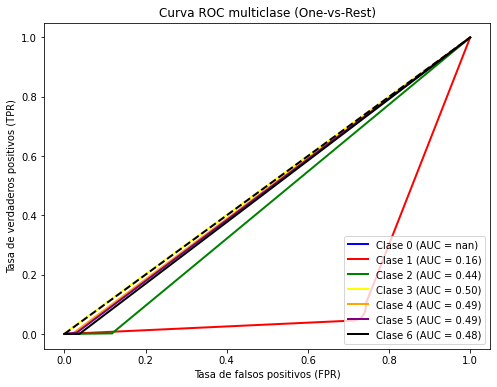

AUC promedio (macro): 0.95


In [51]:
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="f1",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
AUC_curvas(best_model)

Ahora hagamos la validacion cruzada anidada usando class = 'balanced'

In [ ]:
tree = DecisionTreeClassifier(random_state = 42, class_weight="balanced")
param_grid = {
    "max_depth": [10, 20, 30, None],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", None],
}

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_B = grid_search.best_estimator_


Precisión: 94.24%
Matriz de confusión:
[[40161  2188     1     0    35     4   168]
 [ 2246 53743   144     0   227   115    25]
 [    2   141  6646    57    20   255     0]
 [    0     1    71   434     0    20     0]
 [   30   263    13     0  1679    10     0]
 [   10   138   306    16    10  3009     0]
 [  157    26     0     0     0     0  3832]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.95      0.95     56500
           3       0.93      0.93      0.93      7121
           4       0.86      0.83      0.84       526
           5       0.85      0.84      0.85      1995
           6       0.88      0.86      0.87      3489
           7       0.95      0.95      0.95      4015

    accuracy                           0.94    116203
   macro avg       0.91      0.90      0.91    116203
weighted avg       0.94      0.94      0.94    116203



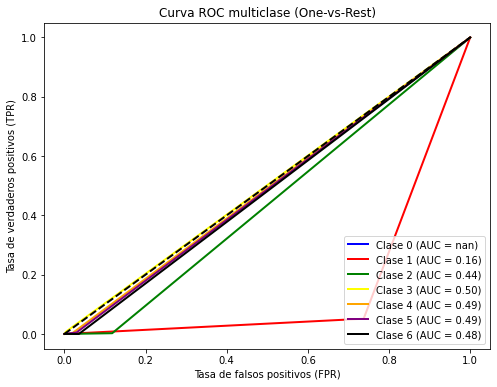

AUC promedio (macro): 0.94


In [53]:
metricas(best_model_B)
AUC_curvas(best_model_B)

In [60]:
tree = DecisionTreeClassifier(random_state = 42, criterion="entropy")

start = time.process_time()  # Inicia el contador de CPU time
tree.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print("Accuracy on training set: {:.3f}".format(tree.score(X_train_ADA, y_train_ADA)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

print(f"CPU Time: {end - start} segundos")

Accuracy on training set: 1.000
Accuracy on test set: 0.942
CPU Time: 21.9375 segundos


CPU Time: 22.890625 segundos
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'max_features': None}
Precisión: 94.59%
Matriz de confusión:
[[40206  2092     3     0    37    10   209]
 [ 2207 53641   176     1   286   156    33]
 [    1    91  6759    45    17   208     0]
 [    0     0    53   453     0    20     0]
 [   17   167    15     0  1790     6     0]
 [    6    76   182    25    11  3189     0]
 [  119    21     0     0     1     0  3874]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.96      0.95      0.95     56500
           3       0.94      0.95      0.94      7121
           4       0.86      0.86      0.86       526
           5       0.84      0.90      0.87      1995
           6       0.89      0.91      0.90      3489
           7       0.94      0.96      0.95      4015

    accuracy                           0.95    116203
   macro av

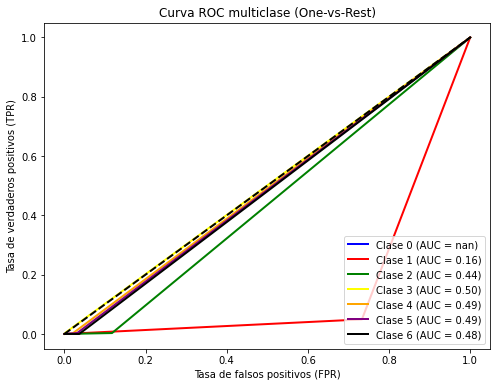

AUC promedio (macro): 0.96


In [57]:
tree = DecisionTreeClassifier(random_state = 42)
param_grid = {
    "max_depth": [10, 20, 30, None],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", None],
}

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_ADA, y_train_ADA)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_ADA = grid_search.best_estimator_

metricas(best_model_ADA)
AUC_curvas(best_model_ADA)

CPU Time: 21.90625 segundos
Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'max_features': None}
Precisión: 94.59%
Matriz de confusión:
[[40206  2092     3     0    37    10   209]
 [ 2207 53641   176     1   286   156    33]
 [    1    91  6759    45    17   208     0]
 [    0     0    53   453     0    20     0]
 [   17   167    15     0  1790     6     0]
 [    6    76   182    25    11  3189     0]
 [  119    21     0     0     1     0  3874]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.96      0.95      0.95     56500
           3       0.94      0.95      0.94      7121
           4       0.86      0.86      0.86       526
           5       0.84      0.90      0.87      1995
           6       0.89      0.91      0.90      3489
           7       0.94      0.96      0.95      4015

    accuracy                           0.95    116203
   macro avg

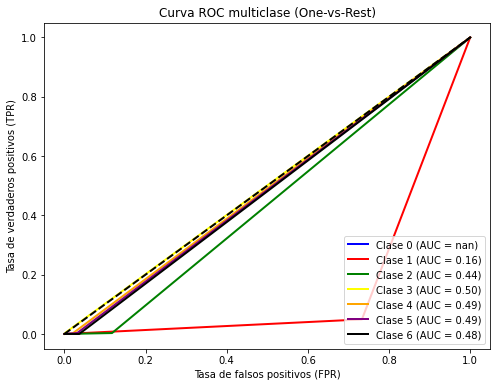

AUC promedio (macro): 0.96


In [55]:
tree = DecisionTreeClassifier(random_state = 42)
param_grid = {
    "max_depth": [10, 20, 30, None],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2", None],
}

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_SM = grid_search.best_estimator_

metricas(best_model_SM)
AUC_curvas(best_model_SM)

Ahora comparamos los mejores modelos de los grid search en cada metodo de balanceo

In [61]:
print("Accuracy on test set: {:.3f}".format(best_model.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_B.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_SM.score(X_test, y_test)))
print("Accuracy on test set: {:.3f}".format(best_model_ADA.score(X_test, y_test)))

AUC_curvas(best_model, draw = False)
AUC_curvas(best_model_B, draw = False)
AUC_curvas(best_model_SM, draw = False)
AUC_curvas(best_model_ADA, draw = False)

Accuracy on test set: 0.939
Accuracy on test set: 0.942
Accuracy on test set: 0.946
Accuracy on test set: 0.946
AUC promedio (macro): 0.95
AUC promedio (macro): 0.94
AUC promedio (macro): 0.96
AUC promedio (macro): 0.96


In [62]:
results = pd.DataFrame(grid_search.cv_results_)

In [63]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,8.868130,0.291849,0.304447,0.027691,gini,10,sqrt,"{'criterion': 'gini', 'max_depth': 10, 'max_fe...",0.734900,0.630555,0.632953,0.728314,0.673782,0.680101,0.044822,22
1,7.817384,0.344732,0.279783,0.027987,gini,10,log2,"{'criterion': 'gini', 'max_depth': 10, 'max_fe...",0.610518,0.678013,0.683189,0.604902,0.628393,0.641003,0.033290,23
2,36.442931,0.532699,0.243282,0.009532,gini,10,None,"{'criterion': 'gini', 'max_depth': 10, 'max_fe...",0.794776,0.799841,0.795998,0.795113,0.797661,0.796678,0.001871,20
3,12.871043,0.646687,0.390202,0.077225,gini,20,sqrt,"{'criterion': 'gini', 'max_depth': 20, 'max_fe...",0.872680,0.897009,0.899673,0.898312,0.873275,0.888190,0.012451,16
4,11.124554,0.304768,0.363749,0.022682,gini,20,log2,"{'criterion': 'gini', 'max_depth': 20, 'max_fe...",0.847324,0.869962,0.886272,0.873463,0.884033,0.872211,0.013881,18


CPU Time: 23.921875 segundos
Mejores hiperparámetros: {'max_depth': 37}
Precisión: 94.60%
Matriz de confusión:
[[40215  2083     3     0    36    10   210]
 [ 2203 53649   176     1   279   157    35]
 [    1    89  6761    45    17   208     0]
 [    0     0    53   453     0    20     0]
 [   17   160    15     0  1795     8     0]
 [    6    76   182    25    11  3189     0]
 [  127    17     0     0     1     0  3870]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.96      0.95      0.95     56500
           3       0.94      0.95      0.94      7121
           4       0.86      0.86      0.86       526
           5       0.84      0.90      0.87      1995
           6       0.89      0.91      0.90      3489
           7       0.94      0.96      0.95      4015

    accuracy                           0.95    116203
   macro avg       0.91      0.93      0.92    116203
weigh

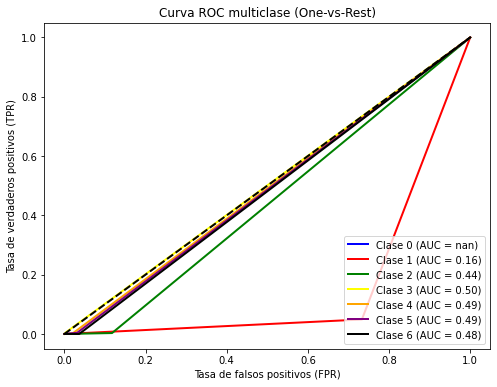

AUC promedio (macro): 0.96


In [64]:
tree = DecisionTreeClassifier(random_state = 42, criterion = "entropy")
param_grid = {
    "max_depth": [33, 34, 35, 36, 37, 38, 39, None],
}

# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)

start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train_SM, y_train_SM)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
new_best_model_SM = grid_search.best_estimator_
metricas(new_best_model_SM)
AUC_curvas(new_best_model_SM)

In [65]:
results = pd.DataFrame(grid_search.cv_results_)

In [66]:
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,58.102596,2.402008,0.390272,0.020762,33,{'max_depth': 33},0.978587,0.981318,0.981340,0.982874,0.985834,0.981991,0.002367,4
1,58.038668,2.935734,0.371142,0.034790,34,{'max_depth': 34},0.978540,0.981116,0.981456,0.982930,0.985717,0.981952,0.002355,8
2,57.238262,1.054348,0.372566,0.045499,35,{'max_depth': 35},0.978565,0.981299,0.981431,0.982952,0.985787,0.982007,0.002360,2
3,56.895230,0.720797,0.371112,0.034286,36,{'max_depth': 36},0.978565,0.981204,0.981365,0.982952,0.985765,0.981970,0.002363,7
4,57.812879,2.045908,0.387681,0.038477,37,{'max_depth': 37},0.978565,0.981208,0.981400,0.982946,0.985998,0.982023,0.002436,1
5,60.288899,0.836808,0.380824,0.031038,38,{'max_depth': 38},0.978565,0.981151,0.981400,0.982902,0.985925,0.981989,0.002412,5
6,58.718479,1.097751,0.322071,0.032891,39,{'max_depth': 39},0.978565,0.981245,0.981400,0.982952,0.985831,0.981999,0.002379,3
7,57.579231,0.553966,0.242997,0.062690,None,{'max_depth': None},0.978565,0.981245,0.981400,0.982820,0.985866,0.981979,0.002381,6


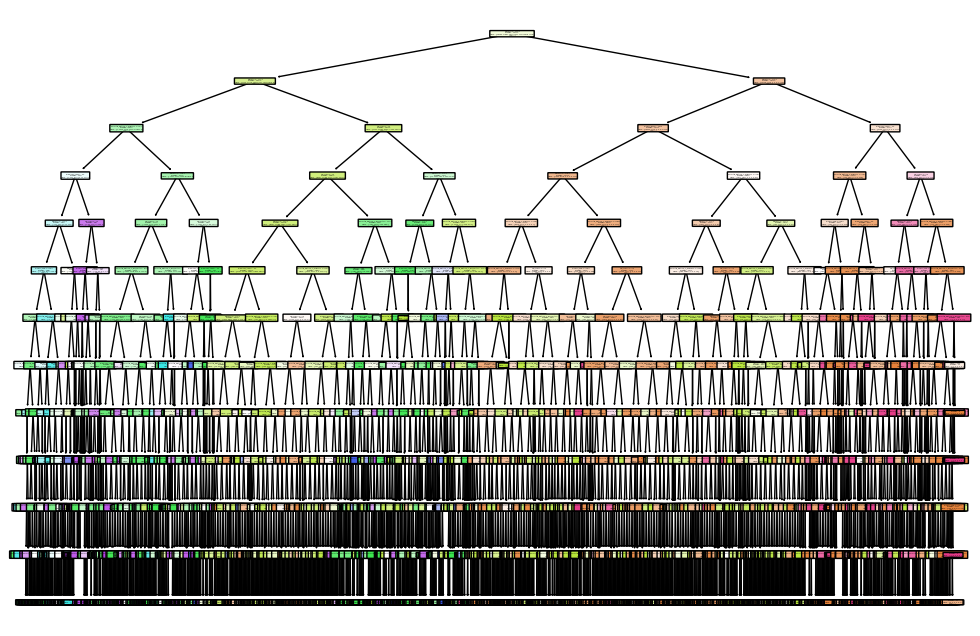

In [97]:
plt.figure(figsize=(12, 8))
plot_tree(
    tree,
    class_names=["1", "2", "3", "4", "5", "6", "7"],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    impurity = False
)
plt.show()

In [103]:
def plot_feature_importances_cancer(model):
    n_features = 54
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

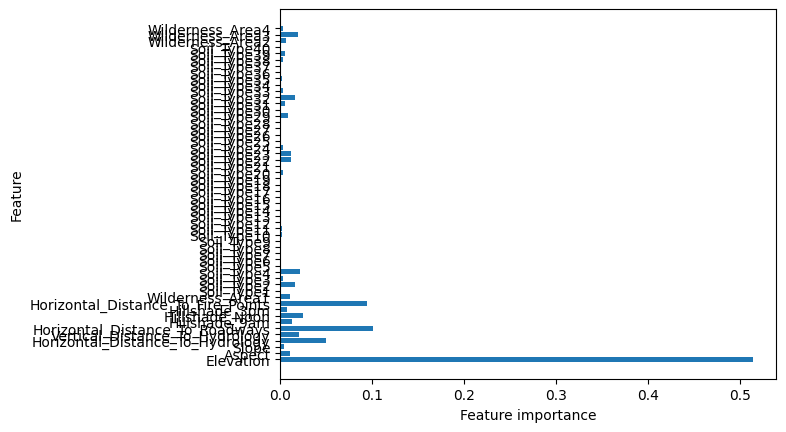

In [104]:
plot_feature_importances_cancer(tree)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [112]:
# Entrenar modelo
rTree = RandomForestClassifier(random_state = 42, n_estimators = 100)
start = time.process_time()  # Inicia el contador de CPU time
rTree.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print("Accuracy on training set: {:.3f}".format(rTree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(rTree.score(X_test, y_test)))

print(f"CPU Time: {end - start} segundos")

# Evaluar
y_pred = rTree.predict(X_test)
print(classification_report(y_test, y_pred))

Accuracy on training set: 1.000
Accuracy on test set: 0.955
CPU Time: 108.640625 segundos
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42557
           2       0.95      0.97      0.96     56500
           3       0.94      0.97      0.96      7121
           4       0.92      0.85      0.89       526
           5       0.94      0.77      0.85      1995
           6       0.94      0.90      0.92      3489
           7       0.97      0.95      0.96      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.96    116203



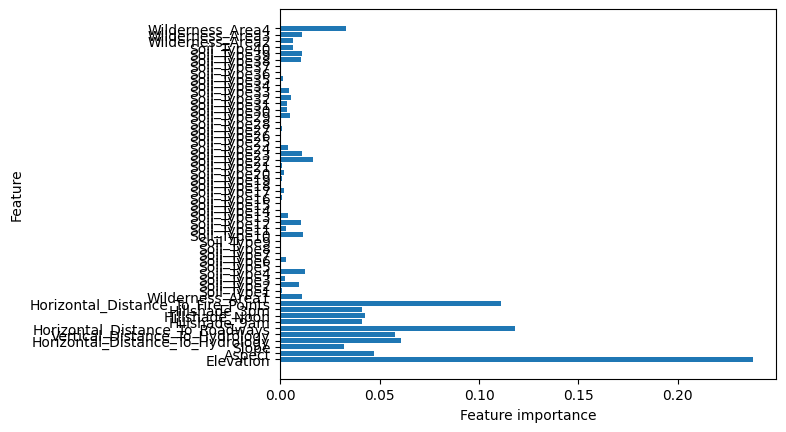

In [113]:
plot_feature_importances_cancer(rTree)

In [ ]:
rTree = RandomForestClassifier(random_state = 42, criterion = "entropy", class_weight = "balanced")
param_grid = {
    "n_estimators" : [50, 100, 150],
    "max_features" : ["log2", "sqrt", None],
    "max_depth" : [35, None]
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model_B = grid_search.best_estimator_

metricas(best_model_B)
AUC_curvas(best_model_B)

## XGBoost

In [2]:
from sklearn.ensemble import GradientBoostingClassifier

In [17]:
gbrt = GradientBoostingClassifier(random_state = 42)
gbrt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 0.775
Accuracy on test set: 0.772


Precisión: 77.20%
Matriz de confusión:
[[31941 10120    13     0    17    18   448]
 [ 8830 46695   490     0   109   344    32]
 [    0   675  5881    83     5   477     0]
 [    0     0   131   381     0    14     0]
 [   25  1470    49     0   445     6     0]
 [    0   786  1104    28     1  1570     0]
 [ 1186    33     0     0     0     0  2796]]
Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.76      0.75      0.76     42557
           2       0.78      0.83      0.80     56500
           3       0.77      0.83      0.80      7121
           4       0.77      0.72      0.75       526
           5       0.77      0.22      0.35      1995
           6       0.65      0.45      0.53      3489
           7       0.85      0.70      0.77      4015

    accuracy                           0.77    116203
   macro avg       0.76      0.64      0.68    116203
weighted avg       0.77      0.77      0.77    116203



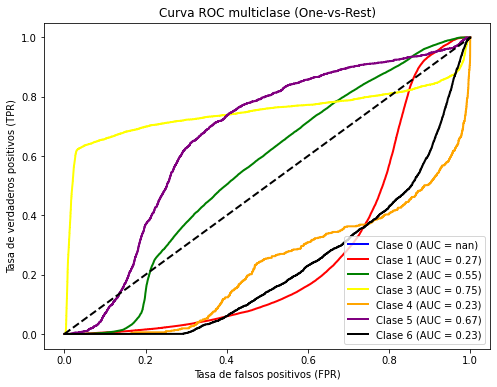

AUC promedio (macro): 0.96


In [18]:
metricas(gbrt)
AUC_curvas(gbrt)

## SVM

In [19]:
from sklearn.svm import SVC

In [ ]:
svm = SVC(gamma = 1, C = 1)
svm.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(svm.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(svm.score(X_test, y_test)))

In [ ]:
svm = SVC(random_state = 42)
param_grid = {
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
}
# Configurar Grid Search
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="accuracy",  # Métrica de evaluación
    cv=5,  # Validación cruzada de 5 folds
    n_jobs=-1,  # Usar todos los núcleos de la CPU
)
start = time.process_time()  # Inicia el contador de CPU time
# Ejecutar Grid Search
grid_search.fit(X_train, y_train)
end = time.process_time()  # Finaliza el contador de CPU time
print(f"CPU Time: {end - start} segundos")

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_

metricas(best_model)
AUC_curvas(best_model)